In [1]:
import sys
sys.path.insert(1, "/mnt/c/Users/PC/Desktop/wikolego-repository/ai-path/projects/image-to-black-white/src")

In [3]:
import os
from PIL import Image


# Sciezki folderow
folder_zrodlowy = "../data"
folder_docelowy = "../out"


# Tworzenie folderu docelowego, jesli nie istnieje
if not os.path.exists(folder_docelowy):
    os.makedirs(folder_docelowy)


# Lista rozszerzen plikow do konwersji
rozszerzenia = [".jpg", ".jpeg", ".png"]


# Petla po plikach w folderze zrodlowym
for nazwa_pliku in os.listdir(folder_zrodlowy):
    # Sprawdzanie, czy plik ma odpowiednie rozszerzenie
    
    sciezka_zrodlowa = ""
    
    if any(nazwa_pliku.lower().endswith(ext) for ext in rozszerzenia):
        # Tworzenie pelnej sciezki do pliku zrodlowego
        sciezka_zrodlowa = os.path.join(folder_zrodlowy, nazwa_pliku)


    try:
        # Otwieranie obrazu
        obraz = Image.open(sciezka_zrodlowa)


        # Tworzenie nazwy pliku docelowego
        nazwa_pliku_docelowego = os.path.splitext(nazwa_pliku)[0] + ".jpg"
        sciezka_docelowa = os.path.join(
        folder_docelowy, nazwa_pliku_docelowego
        )


        # Konwersja i zapisywanie obrazu
        obraz = obraz.convert("RGB")  # Konwersja do trybu RGB
        obraz.save(sciezka_docelowa, "JPEG")


        print(f"Skonwertowano i zapisano: {nazwa_pliku} -> {nazwa_pliku_docelowego}")
    except Exception as e:
        print(f"Blad podczas konwersji {nazwa_pliku}: {e}")


print("Konwersja zakonczona.")

Blad podczas konwersji .ipynb_checkpoints: 'str' object has no attribute 'read'
Skonwertowano i zapisano: image1.jpeg -> image1.jpg
Skonwertowano i zapisano: image2.jpg -> image2.jpg
Skonwertowano i zapisano: image3.jpg -> image3.jpg
Skonwertowano i zapisano: image4.png -> image4.jpg
Skonwertowano i zapisano: image5.jpg -> image5.jpg
Konwersja zakonczona.


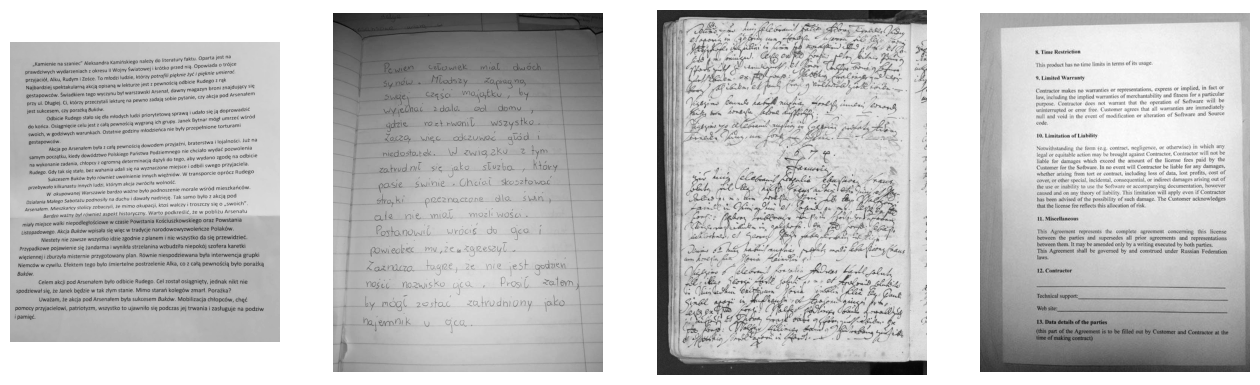

In [5]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

nazwy_plikow = [
    # "../out/image1.jpg",
    "../out/image2.jpg",
    "../out/image3.jpg",
    "../out/image4.jpg",
    "../out/image5.jpg"
]

kernel1 = np.array([[-1,  -1, -1],
                   [-1,  8,  -1],
                   [-1, -1,  -1]])

kernel2 = np.array([[1,  0, -1], 
                    [0,  0,  0], 
                    [-1, 0,  1]])


columns = 4
rows = 1

fig = plt.figure(figsize=(16, 8))

images = []

index = 1
for nazwa_pliku in nazwy_plikow:
    if not os.path.exists(nazwa_pliku):
        print("plik", nazwa_pliku, "nie istnieje")
        continue
        
    img = cv2.imread(nazwa_pliku)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # img = cv2.filter2D(img, -1, kernel1)
    
    images.append(img)
    
    fig.add_subplot(rows, columns, index)
    plt.axis('off')
    plt.imshow(img, cmap=plt.get_cmap('gray'))
    
    index += 1
    
plt.show()
    

# plt.imshow(img, cmap=plt.get_cmap('gray'))

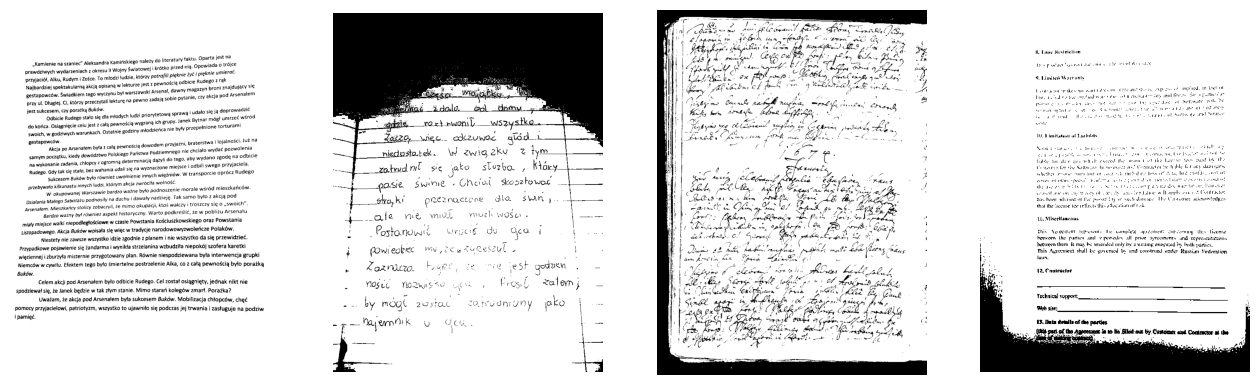

In [6]:
columns = 4
rows = 1

prog = 127
index = 1
# print(len(images))

fig = plt.figure(figsize=(16, 8))

images_cp = images

for img in images_cp:
    # histogram = cv2.calcHist([img], [0], None, [256], [0, 256])
    
    height, width = img.shape
    for r in range(height):
        for c in range(width):
            if img[r, c] <= prog:
                img[r, c] = 0
            else:
                img[r, c] = 255
                
    fig.add_subplot(rows, columns, index)
    plt.axis('off')
    plt.imshow(img, cmap=plt.get_cmap('gray'))
    
    index += 1
    
plt.show()

image sizes
720 - 960
_________________
mean: 179.5027947570183


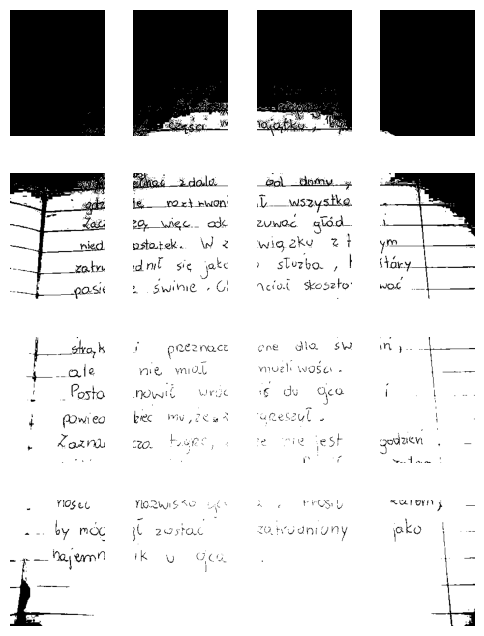

In [58]:
import matplotlib.gridspec as gridspec

image = images[1]
image_height, image_width = image.shape
higher_value = max(image_height, image_width)

rows = 4        # related with height
columns = 4     # related with width

fig = plt.figure(figsize=(8 * image_width / higher_value, 8 * image_height / higher_value))
gs = gridspec.GridSpec(rows, columns, figure=fig, wspace=0.3, hspace=0.3)

image_parts = []
avg_values = []

print("image sizes")
print(image_width, "-", image_height)
print("_________________")

for r in range(rows):
    r_begin = r * image_height // rows
    r_end = (r + 1) * image_height // rows - 1

    for c in range(columns):
        c_begin = c * image_width // columns
        c_end = (c + 1) * image_width // columns - 1
        
        image_part = image[r_begin:r_end, c_begin:c_end]
        
        # print(x_begin, "-", x_end)
        # print(y_begin, "-", y_end)
        # print("_________________")
        
        el = fig.add_subplot(gs[r, c])
        el.axis('off')
        el.imshow(image_part, cmap=plt.get_cmap('gray'))
        
        image_parts.append(image_part)
        avg_values.append(np.mean(image_part))

mean = 0
for x in avg_values:
    # print()
    # print(np.mean(x))
    mean = mean + x
    
mean = mean / (w * h)
print("mean:", mean)

In [ ]:
for image_part in image_parts:
    